# Emoji Usage and Sentiment Analysis in Tweets

## Introduction

Emojis play an important role in online communication by conveying emotions, tone, and contextual cues that may not be fully expressed in text. In social media platforms such as Twitter, emojis often complement or reinforce the sentiment of a message.

This project explores how emojis are distributed across different sentiment labels. Understanding these patterns can help reveal how visual symbols contribute to emotional expression in online discourse.

## Dataset

The dataset used in this project is [TweetFeels 1m4](https://huggingface.co/datasets/mnemoraorg/tweetfeels-1m4), a large-scale collection of labeled tweets available on Hugging Face. Tweets in the dataset frequently include emojis, which makes it a suitable resource for analyzing how emojis are assciated with sentiment labels. 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import emoji

from collections import Counter

import plotly.io as pio
pio.renderers.default = "notebook_connected"
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Load TweetFeels-1m from Hugging Face
from datasets import load_dataset

dataset = load_dataset("mnemoraorg/tweetfeels-1m4")
df = dataset["train"].to_pandas()

df.head()

,Text,Language,Label
0,@Charlie_Corley @Kristine1G @amyklobuchar @Sty...,en,litigious
1,#BadBunny: Como dos gotas de agua: Joven se di...,es,negative
2,https://t.co/YJNiO0p1JV Flagstar Bank disclose...,en,litigious
3,Rwanda is set to host the headquarters of Unit...,en,positive
4,OOPS. I typed her name incorrectly (today’s br...,en,litigious


In [31]:
df.shape

(937854, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 937854 entries, 0 to 937853
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   Text      937854 non-null  object
 1   Language  937831 non-null  object
 2   Label     937854 non-null  object
dtypes: object(3)
memory usage: 21.5+ MB


In [5]:
df.columns = df.columns.str.lower()
df["label"].value_counts()

label
positive       264545
negative       262220
uncertainty    206940
litigious      204149
Name: count, dtype: int64

Text(0.5, 1.0, 'Label Distribution')

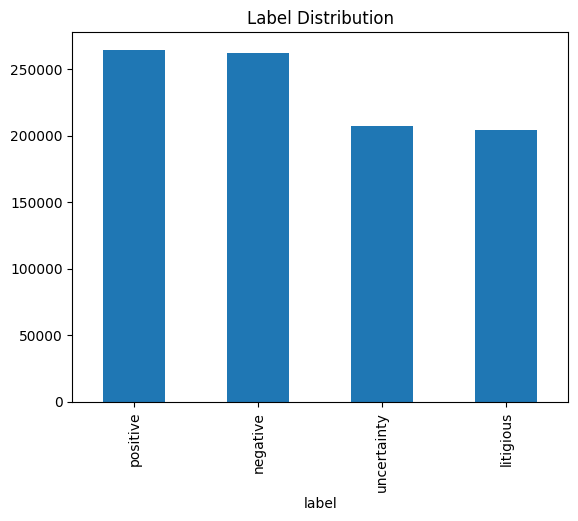

In [6]:
df["label"].value_counts().plot(kind = "bar")
plt.title("Label Distribution")

In [7]:
df["char_len"] = df["text"].str.len()
df["word_len"] = df["text"].str.split().str.len()

df.groupby("label")[["char_len", "word_len"]].mean()

,char_len,word_len
label,,
litigious,175.637054,27.433958
negative,158.675223,26.062097
positive,150.677276,23.523178
uncertainty,161.057316,26.424514


## Emoji Extraction

In [8]:
def extract_emojis(text):
    if pd.isna(text):
        return []
    return [e["emoji"] for e in emoji.emoji_list(text)]

df["emojis"] = df["text"].apply(extract_emojis)

df["emoji_count"] = df["emojis"].str.len()
df["has_emoji"] = df["emoji_count"] > 0

## Emoji Usage Across Labels

In [9]:
usage = df.groupby("label").agg(
    tweets = ("text", "size"),
    emoji_rate = ("has_emoji", "mean"),
    mean_emoji = ("emoji_count", "mean")
)

usage

,tweets,emoji_rate,mean_emoji
label,,,
litigious,204149,0.098795,0.207995
negative,262220,0.142827,0.280982
positive,264545,0.216458,0.471973
uncertainty,206940,0.149990,0.279724


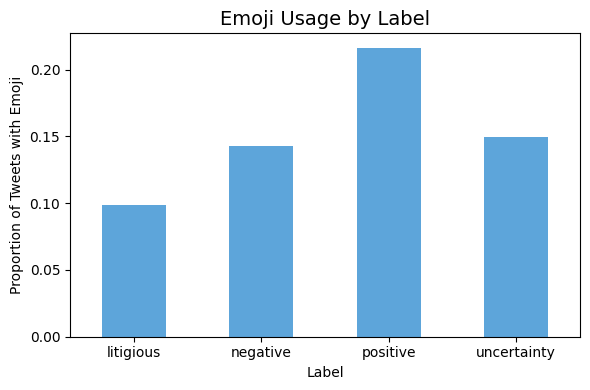

In [12]:
ax = usage["emoji_rate"].plot(
    kind="bar",
    figsize=(6,4),
    color="#5DA5DA"
)

ax.set_title("Emoji Usage by Label", fontsize=14)
ax.set_ylabel("Proportion of Tweets with Emoji")
ax.set_xlabel("Label")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Positive labels tend to contain emojis more frequently.

## Most Frequent Emojis

In [35]:
all_emojis = [e for lst in df["emojis"] for e in lst]

emoji_counts = Counter(all_emojis)

top20 = pd.DataFrame(
    emoji_counts.most_common(20),
    columns = ["emoji", "count"]
)

top20.head()

,emoji,count
0,😂,28717
1,😭,18545
2,🤣,14454
3,❤️,7799
4,🔥,5452


In [17]:
fig = px.bar(
    top20,
    x="count",
    y="emoji",
    orientation="h",
    title="Top 20 Most Used Emojis",
    labels={"count": "Frequency", "emoji": "Emoji"}
)

fig.update_layout(yaxis=dict(categoryorder="total ascending"))

fig.show()

In [51]:
emoji_df = df.explode("emojis")

emoji_label_rank = (
    emoji_df
    .groupby(["label", "emojis"])
    .size()
    .reset_index(name="count")
)

top_per_label = (
    emoji_label_rank
    .sort_values(["label", "count"], ascending=[True, False])
    .groupby("label")
    .head(10)
)

In [55]:
fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=top_per_label["label"].unique()
)

labels = top_per_label["label"].unique()

positions = [(1,1),(1,2),(2,1),(2,2)]

for label, (r,c) in zip(labels, positions):

    group = top_per_label[top_per_label["label"] == label]
    
    group = group.sort_values("count")

    fig.add_trace(
        go.Bar(
            x=group["count"],
            y=group["emojis"],
            orientation="h"
        ),
        row=r,
        col=c
    )

fig.update_layout(
    height=700,
    width=900,
    showlegend=False,
    title="Top 10 Emojis by Label"
)

fig.show()

## Emoji-Label Heatmap

In [50]:
emoji_label_counts = pd.crosstab(
    emoji_df["emojis"],
    emoji_df["label"]
)

top_emojis = emoji_label_counts.sum(axis=1).nlargest(20).index
emoji_label_counts = emoji_label_counts.loc[top_emojis]

emoji_label_freq = emoji_label_counts.div(
    emoji_label_counts.sum(axis=1),
    axis=0
)

emoji_label_counts.head()

label,litigious,negative,positive,uncertainty
emojis,,,,
😂,4084,10338,5744,8551
😭,1486,7982,5769,3308
🤣,2805,5482,3284,2883
❤️,492,1175,5058,1074
🔥,1124,757,3084,487


In [ ]:
emoji_label_freq.head()

In [49]:
fig = px.imshow(
    emoji_label_freq.T.values,   # transpose
    x=emoji_label_freq.index,    # emojis
    y=emoji_label_freq.columns,  # labels
    text_auto=".2f",
    color_continuous_scale="YlOrRd"
)

fig.update_xaxes(
    tickmode="array",
    tickvals=list(range(len(emoji_label_freq.index))),
    ticktext=emoji_label_freq.index
)

fig.show()

In [56]:
emoji_counts = emoji_df["emojis"].value_counts()

fig = px.line(
    x=range(len(emoji_counts)),
    y=emoji_counts.values,
    title="Emoji Frequency Distribution",
    labels={"x":"Emoji Rank","y":"Frequency"}
)

fig.show()

The emoji frequency distribution exhibits a strong long-tail pattern: 
a small number of emojis appear very frequently while the majority 
occur only rarely. This distribution is consistent with Zipf-like 
behavior commonly observed in natural language. Because many emojis 
appear only a few times, rare tokens may produce unstable 
statistical associations in later analyses. Therefore, subsequent 
analyses apply a minimum frequency threshold to focus on sufficiently 
represented emojis.

In [57]:
df["emoji_count"] = df["emojis"].apply(len)

fig = px.histogram(
    df,
    x="emoji_count",
    nbins=10,
    title="Number of Emojis per Tweet"
)

fig.show()